Dataset used:
[Garbage Images Dataset (2000/class)](https://www.kaggle.com/datasets/zlatan599/garbage-dataset-classification/data)

## Mount Google Drive
Mount Google Drive to access and store dataset archives and model weights directly from storage.

In [ ]:
# Mount Google Drive so we can access the dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Prepare Dataset
Copy the dataset archive from Google Drive to the local Colab environment and extract its contents.

In [ ]:
from pathlib import Path # handle filesystem paths
# automatically handles path slashes (/ on mac/linux vs \ on windows)

# Define the location of the dataset ZIP file in Google Drive
source_path = Path('/content/drive/MyDrive/AI-ML Folder/ai-ml-zafar-iqbal-projects/trash-classification/dataset/archive-.zip')

destination_path= Path('/content/dataset/')

# check if file exists at source path
if not source_path.is_file():
    print(f"Error: could not find file at {source_path}")
else:
    print("File found")

# create the directory and any missing parent directories
destination_path.mkdir(parents=True, exist_ok=True)
print(f"Directory created at {destination_path}")

File found
Directory created at /content/dataset


In [ ]:
# copying files from drive
import shutil # shell utilities library for high-level file operations

shutil.copy(source_path, destination_path)
print("File copied from drive successfully!")

File copied from drive successfully!


In [ ]:
import zipfile

zip_file_path = '/content/dataset/archive-.zip'

# Extract the ZIP file so the images can be used for training
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/archive')

print("Extracted successfully!")

Extracted successfully!


## Structure Dataset for Ultralytics
Split the raw dataset into `train` (80%) and `val` (20%) directories as required by the Ultralytics YOLO classification format.

In [ ]:
!pip install split-folders[full]

In [ ]:
import splitfolders

input_folder = '/content/archive/Garbage_Dataset_Classification/images'
output_folder = '/content/garbage_dataset'

# Split the dataset into training and validation sets
# 80% is used for training and 20% for validation
splitfolders.ratio(
    input_folder,
    output_folder,
    seed=42,
    ratio=(0.8, 0.2),
    group_prefix=None
)

Copying files: 13901 files [00:04, 2890.28 files/s]


## Train YOLO Classification Model
Install `ultralytics`, initialize the `yolo26s-cls` pre-trained classification model, and train it on the waste dataset.

In [ ]:
# Install the Ultralytics library for YOLO
!pip install -q ultralytics

In [ ]:
# Import YOLO
from ultralytics import YOLO

# Load a pre-trained YOLO classification model
model = YOLO("yolo26s-cls")

In [ ]:
# Train the model on the waste classification dataset
model.train(
    data="/content/garbage_dataset",
    epochs=20,
    imgsz=224,
    batch=32,
    workers=2
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dcf7e12c0b0>
curves: []
curves_results: []
fitness: 0.9782452285289764
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9568500518798828, 'metrics/accuracy_top5': 0.9996404051780701, 'fitness': 0.9782452285289764}
save_dir: PosixPath('/content/runs/classify/train-2')
speed: {'preprocess': 0.09449645559159796, 'inference': 0.5282942535059594, 'loss': 0.0006643254224483221, 'postprocess': 0.0008686134494730355}
top1: 0.9568500518798828
top5: 0.9996404051780701

## Export and Save Trained Weights
Download the best-performing PyTorch model weights (`best.pt`) to the local machine.

In [ ]:
from google.colab import files

# download the model file to your local computer
files.download('/content/runs/classify/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Evaluation & Validation
Load the saved weights to validate performance metrics (Top-1 accuracy) on the validation set.

In [ ]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO("/content/runs/classify/train/weights/best.pt")

In [ ]:
# Evaluate the model on the validation dataset
metrics = model.val()
# Display the Top-1 and Top-5 accuracy
metrics.top1
metrics.top5

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s-cls summary (fused): 47 layers, 5,441,814 parameters, 0 gradients, 12.1 GFLOPs
train: /content/garbage_dataset/train... found 11120 images in 6 classes ✅ 
val: /content/garbage_dataset/val... found 2781 images in 6 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 255.4±85.4 MB/s, size: 6.7 KB)
val: Scanning /content/garbage_dataset/val... 2781 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2781/2781 530.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 174/174 18.8it/s 9.3s
                   all      0.947      0.999
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val


0.9467817544937134

## Run Inference on Test Images
Pass sample images through the trained model to perform classification predictions.

In [ ]:
# Install the Ultralytics library for YOLO
!pip install -q ultralytics

from ultralytics import YOLO

# Load the trained model
model = YOLO("/content/best.pt")
# Make a prediction on the test image
results = model("/content/trash1.jpg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/trash1.jpg: 224x224 trash 1.00, glass 0.00, cardboard 0.00, paper 0.00, plastic 0.00, 253.0ms
Speed: 34.4ms preprocess, 253.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


In [ ]:
top1_id = results[0].probs.top1  # Get predicted class index
top1_label = results[0].names[top1_id]  # Look up the string label

print(f"Predicted class: {top1_label.upper()}")

Predicted class: TRASH


In [ ]:
results[0].names

{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}

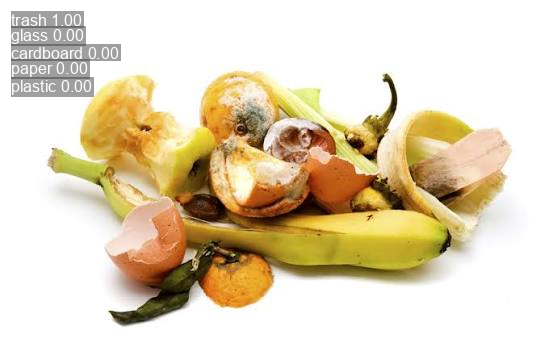

In [ ]:
results[0].show()


image 1/1 /content/trash.jpg: 224x224 metal 0.52, glass 0.38, trash 0.07, plastic 0.03, cardboard 0.01, 5.3ms
Speed: 3.7ms preprocess, 5.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


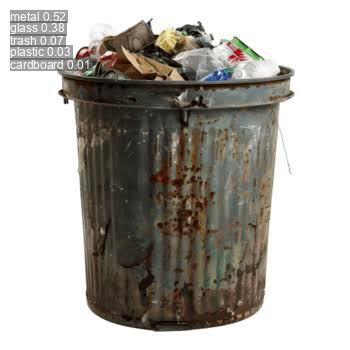

In [ ]:
results = model("/content/trash.jpg")
for result in results:
    result.show()

### Helper Function for Inference
Define a reusable `predict()` function that accepts an image path, runs inference using the trained model, prints the top predicted class, and displays the annotated result image.

In [ ]:
def predict(img_path):
    results = model(img_path)
    for result in results:
        pred_id = result.probs.top1
        pred_label = result.names[pred_id]
        print(f"Predicted class: {pred_label.upper()}")
        result.show()


image 1/1 /content/card.jpg: 224x224 cardboard 1.00, paper 0.00, trash 0.00, plastic 0.00, glass 0.00, 56.0ms
Speed: 7.7ms preprocess, 56.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Predicted class: CARDBOARD


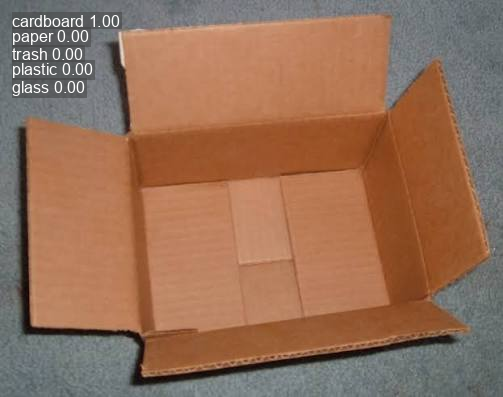

In [ ]:
predict("/content/card.jpg")

## Export Model to ONNX Format
Convert the trained PyTorch model (`best.pt`) to ONNX format (`best.onnx`) for optimized deployment and reduced file size.

In [4]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")
model.export(format="onnx")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26s-cls summary (fused): 47 layers, 5,441,814 parameters, 0 gradients, 1.5 GFLOPs

PyTorch: starting from '/content/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 6) (41.8 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 0.8s, saved as '/content/best.onnx' (20.8 MB)

Export complete (0.9s)
Results saved to /content/best.onnx
Predict:         yolo predict task=classify model=/content/best.onnx imgsz=224 
Validate:        yolo val task=classify model=/content/best.onnx imgsz=224 data=/content/garbage_dataset  
Visualize:       https://netron.app


'/content/best.onnx'